In [2]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

### Setup imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV


### Load the data

In [4]:
MOMP_df_Orig = pd.read_csv('Data/MOMP_Data_KL_2019.csv')

### Preview the data

In [5]:
MOMP_df_Orig.head()

MOMP_df_Orig.shape

(15840, 16)

In [6]:
print(MOMP_df_Orig.columns)

Index(['Unnamed: 0', 'species', 'species.code', 'stop', 'date', 'year',
       'occ.hist', 'julian.z', 'time.m.z', 'cloud.cover.z', 'wind.z',
       'noise.z', 'snow.cover.z', 'precip.z', 'temp.z', 'lat.z'],
      dtype='str')


### Create dataframe

In [7]:
features = ['wind.z', 'noise.z', 'temp.z', 'time.m.z'] # Determine the columns we're using

MOMP_df = MOMP_df_Orig[features + ['occ.hist']].dropna() # Create new dataset with just columns we will use

MOMP_df['occ.hist'] = MOMP_df['occ.hist'].apply( # This changes occ.hist from binary to either just 0 (not detected) or 1 (detected)
    lambda x: 1 if '1' in str(x) else 0
)

X = MOMP_df[features] # Separate inputs and output
y = MOMP_df['occ.hist']

#X = X[:5000] # Limit to first 5000 rows
#y = y[:5000]

MOMP_df.head()

,wind.z,noise.z,temp.z,time.m.z,occ.hist
0,0.485932,-0.59775,0.40585,-0.813241,1
1,0.485932,-0.59775,0.40585,-0.813241,0
2,0.485932,-0.59775,0.40585,-0.813241,0
3,0.485932,-0.59775,0.40585,-0.652362,0
4,0.485932,-0.59775,0.40585,-0.652362,1


### Showing what the data is

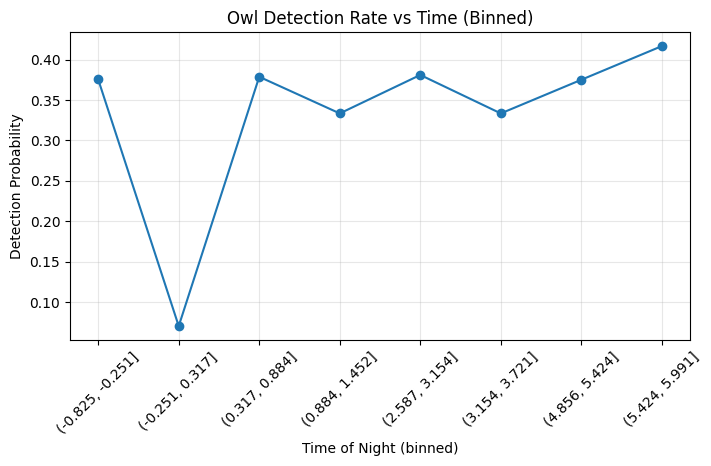

In [8]:
# Bin time into intervals
MOMP_df['time_bin'] = pd.cut(MOMP_df['time.m.z'], bins=12)

# Compute mean detection rate per bin
binned = MOMP_df.groupby('time_bin')['occ.hist'].mean()

# Plot
plt.figure(figsize=(8,4))
binned.plot(marker='o')

plt.title("Owl Detection Rate vs Time (Binned)")
plt.xlabel("Time of Night (binned)")
plt.ylabel("Detection Probability")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

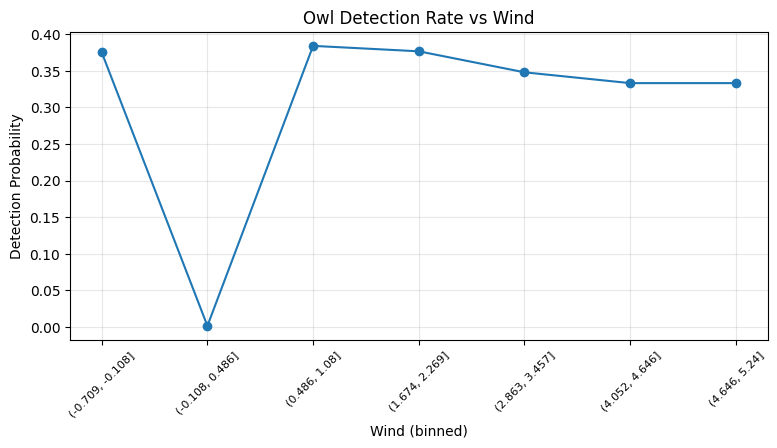

In [28]:
plt.figure(figsize=(9,4))

wind_binned.plot(marker='o', color='tab:blue')

plt.title("Owl Detection Rate vs Wind")
plt.xlabel("Wind (binned)")
plt.ylabel("Detection Probability")

plt.xticks(rotation=45, fontsize=8)
plt.grid(True, alpha=0.3)

plt.show()

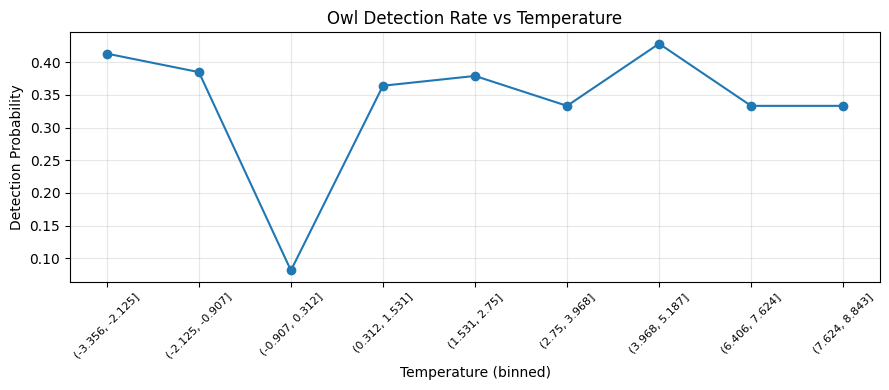

In [29]:
MOMP_df['temp_bin'] = pd.cut(MOMP_df['temp.z'], bins=10)

temp_binned = MOMP_df.groupby('temp_bin')['occ.hist'].mean()

plt.figure(figsize=(9,4))
temp_binned.plot(marker='o', color='tab:blue')

plt.title("Owl Detection Rate vs Temperature")
plt.xlabel("Temperature (binned)")
plt.ylabel("Detection Probability")

plt.xticks(rotation=45, fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

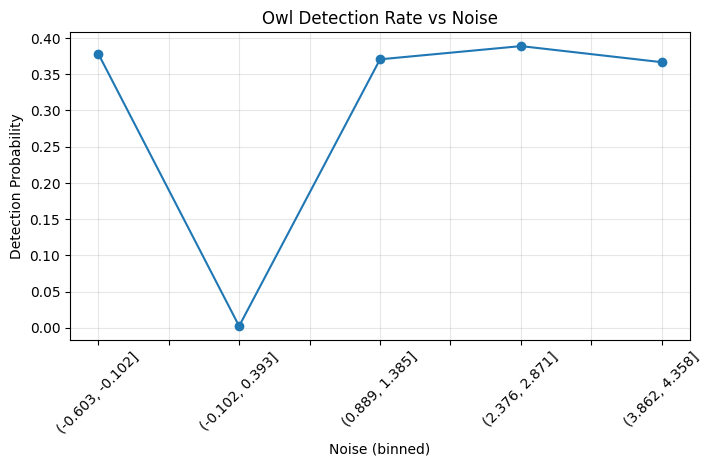

In [27]:
# Bin noise into intervals
MOMP_df['noise_bin'] = pd.cut(MOMP_df['noise.z'], bins=10)

# Compute mean detection rate per bin
noise_binned = MOMP_df.groupby('noise_bin')['occ.hist'].mean()

# Plot
plt.figure(figsize=(8,4))
noise_binned.plot(marker='o')

plt.title("Owl Detection Rate vs Noise")
plt.xlabel("Noise (binned)")
plt.ylabel("Detection Probability")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

### Train-test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Random Forest Classifier

In [11]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8661616161616161


### Random Forest Confusion Matrix

In [12]:
print("Random Forest:\n", classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Random Forest:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93      2787
           1       0.16      0.03      0.05       381

    accuracy                           0.87      3168
   macro avg       0.52      0.50      0.49      3168
weighted avg       0.79      0.87      0.82      3168

Confusion Matrix:
 [[2734   53]
 [ 371   10]]


### Gradient boost

In [13]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [50],
    'learning_rate': [0.1],
    'max_depth': [2]
}

gb_grid = GridSearchCV(gb, gb_params, cv=3)
gb_grid.fit(X_train, y_train)

gb_best = gb_grid.best_estimator_
gb_pred = gb_best.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 0.8794191919191919


### Gradient boost confusion matrix

In [14]:
print("Gradient Boosting:\n", classification_report(y_test, gb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))

Gradient Boosting:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94      2787
           1       0.00      0.00      0.00       381

    accuracy                           0.88      3168
   macro avg       0.44      0.50      0.47      3168
weighted avg       0.77      0.88      0.82      3168

Confusion Matrix:
 [[2786    1]
 [ 381    0]]


### Neural Network

In [15]:
mlp = MLPClassifier(max_iter=500, random_state=42, verbose=False)

mlp_params = {
    'hidden_layer_sizes': [(50,), (100,)],
}

mlp_grid = GridSearchCV(mlp, mlp_params, cv=3)
mlp_grid.fit(X_train, y_train)

mlp_best = mlp_grid.best_estimator_
mlp_pred = mlp_best.predict(X_test)

mlp_acc = accuracy_score(y_test, mlp_pred)
print("Neural Network Accuracy:", mlp_acc)

Neural Network Accuracy: 0.8765782828282829


### Neural network confusion matrix

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print("Neural Network:\n", classification_report(y_test, mlp_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, mlp_pred))

Neural Network:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93      2787
           1       0.19      0.01      0.02       381

    accuracy                           0.88      3168
   macro avg       0.53      0.50      0.47      3168
weighted avg       0.80      0.88      0.82      3168

Confusion Matrix:
 [[2774   13]
 [ 378    3]]


### Comparing models

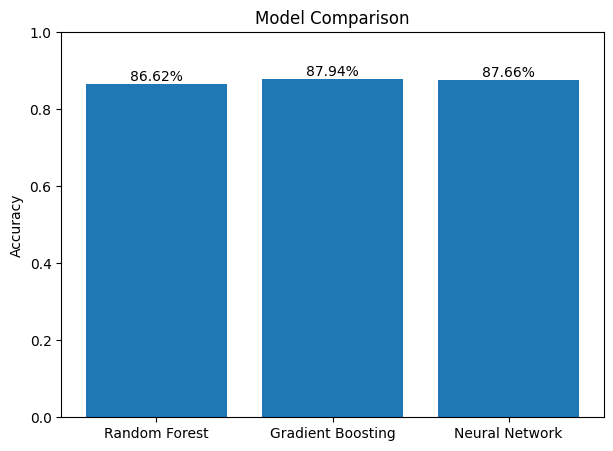

In [17]:
models = ['Random Forest', 'Gradient Boosting', 'Neural Network']
scores = [rf_acc, gb_acc, mlp_acc]

plt.figure(figsize=(7,5))
bars = plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)

# Adding labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{score:.2%}",
        ha='center',
        va='bottom'
    )

plt.show()

### Metrics

In [18]:
def get_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

rf_metrics = get_metrics(y_test, rf_pred)
gb_metrics = get_metrics(y_test, gb_pred)
mlp_metrics = get_metrics(y_test, mlp_pred)

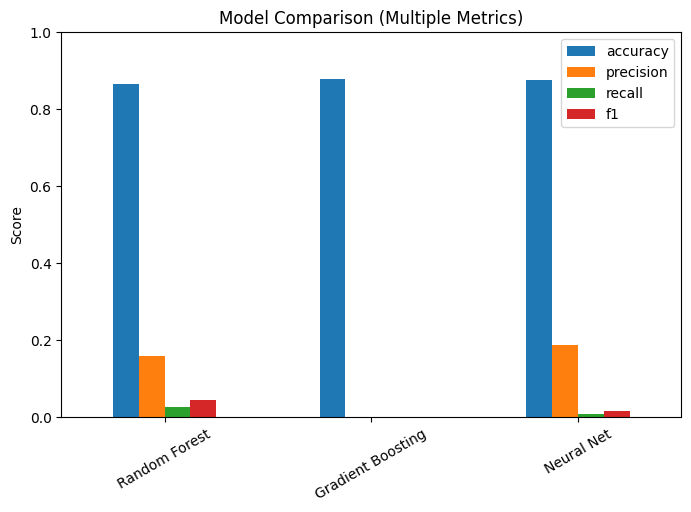

In [19]:
metrics_df = pd.DataFrame([rf_metrics, gb_metrics, mlp_metrics],
                          index=["Random Forest", "Gradient Boosting", "Neural Net"])

metrics_df.plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison (Multiple Metrics)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.show()

### Feature importances from RandomForest

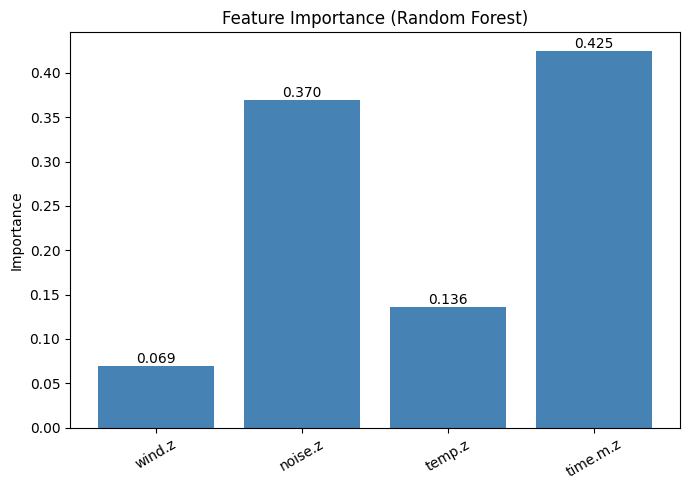

In [20]:
importances = rf_best.feature_importances_
features = X_train.columns

plt.figure(figsize=(7,5))
bars = plt.bar(features, importances, color="steelblue")

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation=30)

# Adding values on top of bars
for bar, imp in zip(bars, importances):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{imp:.3f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Neural network loss curve

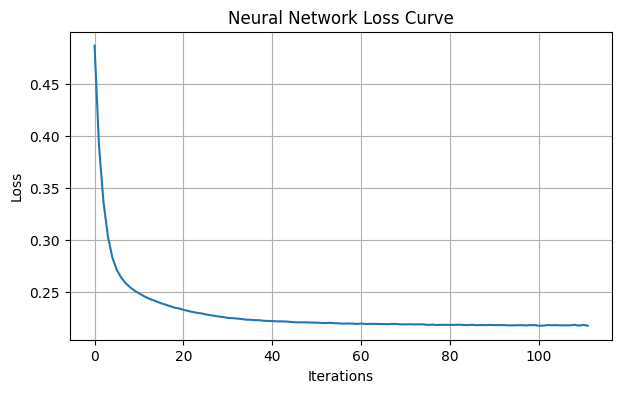

In [21]:
plt.figure(figsize=(7,4))
plt.plot(mlp_best.loss_curve_)

plt.title("Neural Network Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

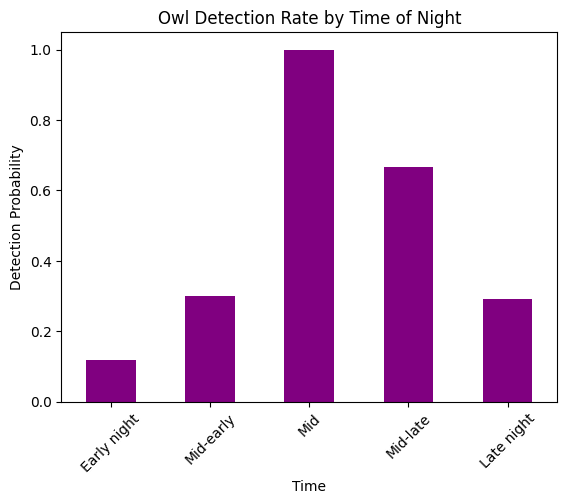

In [22]:
temp_df = X_test.copy()
temp_df['occ.hist'] = y_test

temp_df['time_bin'] = pd.cut(temp_df['time.m.z'], bins=5, labels=[
    "Early night",
    "Mid-early",
    "Mid",
    "Mid-late",
    "Late night"
])

grouped = temp_df.groupby('time_bin')['occ.hist'].mean()

grouped.plot(kind='bar', color='purple')

plt.title("Owl Detection Rate by Time of Night")
plt.xlabel("Time")
plt.ylabel("Detection Probability")
plt.xticks(rotation=45)
plt.show()

### What-if / Sensitivity analysis

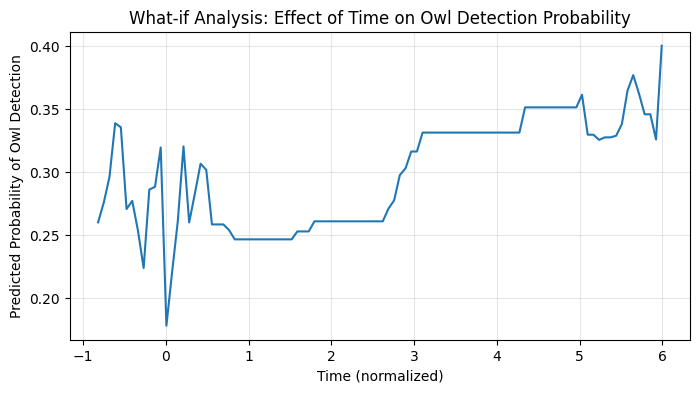

In [23]:
sample = X_test.iloc[0].copy() # Making a copy so we can adjust one of the variable (time)

time_range = np.linspace( # This creates a range of times that will be used
    X['time.m.z'].min(),
    X['time.m.z'].max(),
    100
)

probs = []

for t in time_range:
    temp = sample.copy()
    temp['time.m.z'] = t # Changing the time while keeping everything else constant

    prob = rf_best.predict_proba(pd.DataFrame([temp]))[0][1] # Asking the model what it thinks, but now with the new time
    probs.append(prob)

plt.figure(figsize=(8,4))
plt.plot(time_range, probs)

plt.title("What-if Analysis: Effect of Time on Owl Detection Probability")
plt.xlabel("Time (normalized)")
plt.ylabel("Predicted Probability of Owl Detection")
plt.grid(True, alpha=0.3)

plt.show()